# <font color=Blue>Unit 3-Part 1: 置信区间 </font>

updated on 2026-03-24

In [37]:

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

##  Demo 1 : 单样本均值的置信区间估计  
### 数值类型数据的置信区间 Z-Distribution  （总体$\sigma$已知）
Poplulation (normal distribution) variance  $\sigma^2$  is <font color=red size=4>known</font>-- using Z-distribution , for  a confidence level of $(1-\alpha)\%$ is : <br>
$CI=\bar{x}\pm Z_{\alpha/2}\frac{\sigma}{\sqrt{n}}$

In [38]:
# Known variance, z-disribution
# 定义函数来着
def mean_ci_z(data,ci,sigma):
    n=len(data)
    m,sem=np.mean(data),sigma/np.sqrt(n)
    moe=stats.norm.isf((1-ci)/2,0,1)*sem
    return m-moe,m+moe

In [39]:
mean,sigma,ns=5,5,25
sample=stats.norm.rvs(mean,sigma,ns,random_state=165)
sample

array([ 7.02974152, 10.71308868,  3.66969388,  7.42634747,  1.87882046,
        8.57708064,  6.6891943 ,  9.14460867,  1.62764185,  7.7254471 ,
       -0.48471885,  7.59268426,  9.71535808,  9.13090816, -1.68375454,
       12.44184313,  0.2299109 ,  3.91275924,  2.00878983, -1.71355996,
        1.82020993,  6.09739904,  2.83926909, -2.04646929, 11.27837195])

In [40]:
ci_l,ci_h=mean_ci_z(sample,0.99,5)

print("The sample mean is: ", np.mean(sample).round(2))
print("The 95% confidence interval is: [{:.2f}, {:.2f}]".format(ci_l,ci_h))
# 我们有 99% 的信心认为该置信区间包含总体真实均值。
# 对单次区间而言，是否包含真实均值是确定的（概率 0 或 1）。
# 若多次重复抽样，则约有 99% 的区间会包含总体均值。
# 并不代表 99% 的观测值落在该区间内。

The sample mean is:  5.02
The 95% confidence interval is: [2.45, 7.60]


## Demo 2: 置信区间变化演示 Demo of CI Dancing
1. 我们仿真一个总体（population,N=1000）：data （实际大多数情况下是未知的）
2. 然后从这个总体中采样（Sample，n=30）：sample_i
3. 对于每一个sample_i，分别计算置信区间: CI_i
4. 然后画出置信区间CI_i的变化，并观察其是否包含总体均值（mu）

In [41]:
sigma=3  # 总体方差
mu=5   #总体均值
ci=0.95  #置信区间
Nsamp=100 # 采样个数
nsize=30  #每个样本大小

##
data=stats.norm.rvs(mu,sigma,1000,random_state=121)
CI=(0,0)

for i in np.arange(Nsamp):
    sample_i=np.random.choice(data,nsize,replace=True)
    CI=np.vstack((CI,mean_ci_z(sample_i,ci,sigma)))
CI=CI[1:]
CIoutcomes=pd.DataFrame(CI) #保存每个样本的置信区间范围
CIoutcomes.columns=["CL","CH"]
CIoutcomes["Sample"]=np.arange(Nsamp)+1 

In [42]:
CIoutcomes.head()

,CL,CH,Sample
0,4.358340,6.505373,1
1,3.309231,5.456264,2
2,4.988398,7.135431,3
3,3.403754,5.550787,4
4,3.756159,5.903192,5


Text(0.5, 0, 'Sampling Index')

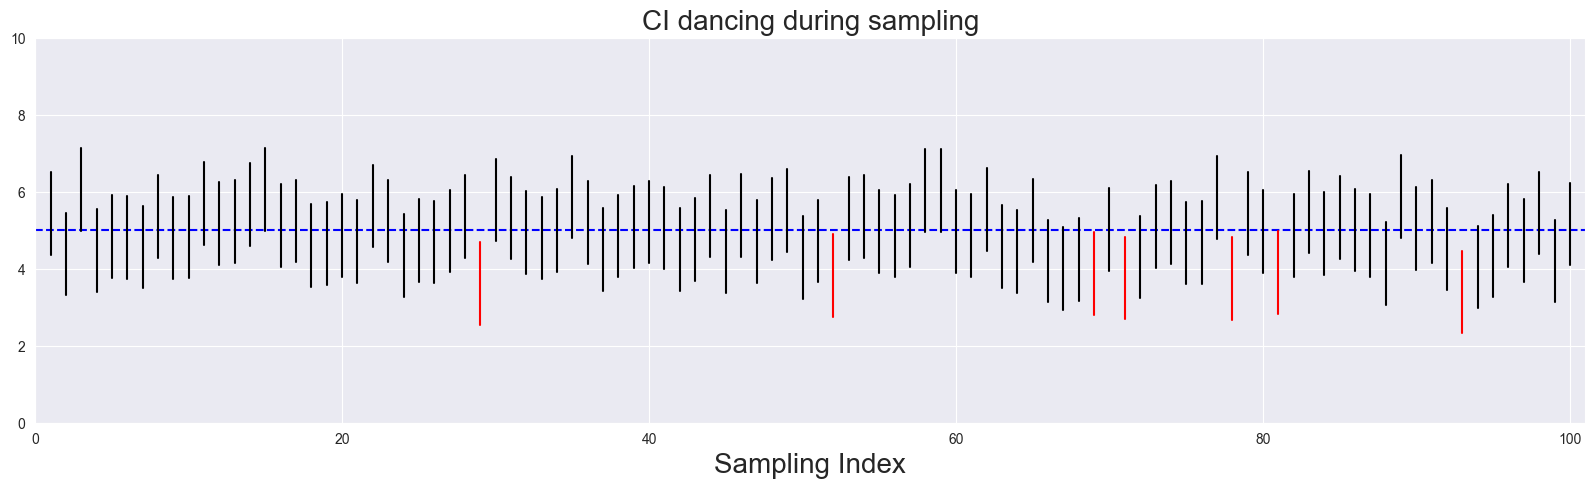

In [43]:
# now we've got Nsamp CIs, let's visulize them
# 不包括总体均值的置信区间用红色表示
sns.set_style("darkgrid")
plt.figure(figsize=(20,5))
plt.axhline(y=mu, ls='--', c='blue')
plt.ylim(0, 10)
plt.xlim(0, Nsamp+1)

for i in np.arange(Nsamp):
    ci_color="black"
    if (mu<CIoutcomes.CL[i]) or (mu>CIoutcomes.CH[i]):
        ci_color="red"
    plt.plot([CIoutcomes.Sample[i],CIoutcomes.Sample[i]], [CIoutcomes.CL[i],CIoutcomes.CH[i]],color=ci_color)
plt.title("CI dancing during sampling",size=20)
plt.xlabel("Sampling Index",size=20)

##  Demo 3:  单样本 t-Distribution
### 数值类型数据的置信区间 t-Distribution  （总体$\sigma$未知）
Poplulation (normal distribution) variance  $\sigma^2$  is <font color=red size=4>unknown</font>-- using t-distribution , for  a confidence level of $(1-\alpha)\%$ is : <br>
$CI=\bar{x}\pm t_{\alpha/2,df}\cdot \frac{s}{\sqrt{n}}$ <br>
$df=n-1$

In [44]:
# Variance unknown: t distribution
def mean_ci_t(data,ci):
    n=len(data)
    std=np.std(data,ddof=1)
    m,sem=np.mean(data),std/np.sqrt(n)
    moe=stats.t.isf((1-ci)/2,n-1)*sem
    return m-moe,m+moe

In [45]:
mean,sigma,ns=5,5,25
sample=stats.norm.rvs(mean,sigma,ns)

In [46]:
ci_l,ci_h=mean_ci_t(sample,0.95)   
print("The 95% confidence interval is: [{:.2f}, {:.2f}]".format(ci_l,ci_h))


ci_l,ci_h=mean_ci_z(sample,0.95,sigma)   
print("The 95% confidence interval is: [{:.2f}, {:.2f}]".format(ci_l,ci_h))

The 95% confidence interval is: [3.96, 9.06]
The 95% confidence interval is: [4.55, 8.47]


## Demo-4: 两个样本的均值差异的置信区间

* 配对样本
* 独立样本，总体方差已知
* 独立样本，总体方差相等，但未知
* 独立样本，总体方差未知，且不等

### 4-1： 配对样本 t-检验

In [47]:
### CI for the difference between the means (dmean) of two dependent/paired samples
def dmean_ci_paired(data1,data2,alpha=0.05):
    x=np.array(data1)-np.array(data2)  ### paired difference sample
    t_crit=stats.t.isf(alpha/2,len(x)-1,0,1)
    moe=t_crit*np.std(x,ddof=1)/np.sqrt(len(x))
    return np.mean(x)-moe,np.mean(x)+moe

In [48]:
### 12个糖尿病人治疗前后的空腹血糖值mmol/l
data1=[7.1,8.2,8.5,9,8.2,6.7,6.3,6.4,7.2,8.5,9.2,6.8]
data2=[5.3,5.9,6.0,7.2,7.2,6.5,6.0,4.5,5.1, 5.0,7.5,6.0]
ci_l,ci_h=dmean_ci_paired(data1,data2,alpha=0.05)
print("The mean difference btw the two paired samples by t-Distribution is:[", ci_l, ", ", ci_h,"]")

The mean difference btw the two paired samples by t-Distribution is:[ 1.0540738126593965 ,  2.26259285400727 ]


### 4-2：两个 独立样本差异（总体方差已知）： Z-检验

The CI of $\mu_1-\mu_2$ is calcluated with Z-distribution:<br>
$CI=(\bar{x}_1-\bar{x}_2)\pm Z_{\alpha/2} \sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}}$

In [49]:
### CI for the difference between the means of two dependent/paired samples
def dmean_ci_ind_z(data1,data2,sigma1,sigma2, alpha=0.05):
    Za=stats.norm.isf(alpha/2,0,1)
    moe=Za*np.sqrt(sigma1**2/len(data1)+sigma2**2/len(data2))
    M=np.mean(data1)-np.mean(data2)
    return M-moe,M+moe

In [50]:
### 随机招募24个病人， 一组吃药，一组未吃药（模拟数据，暂不考虑伦理问题），计算两组血糖均值差异的置信区间（mmol/l）
### with known variances of Var1=1.1, Var2=0.9 in two groups respectively
import numpy as np
import scipy.stats as stats
data1=np.array([7.1,8.2,8.5,9,8.2,6.7,6.3,6.4,7.2,8.5,9.2,6.8])
data2=np.array([5.3,5.9,6.0,7.2,7.2,6.5,6.0,4.5,5.1, 5.0,7.5,6.0])
Var1=1.1
Var2=0.9
alpha=0.05
print(dmean_ci_ind_z(data1,data2,np.sqrt(Var1),np.sqrt(Var2),alpha=0.05))

(np.float64(0.8581813872741156), np.float64(2.4584852793925527))


### 4-3：两个 独立样本差异（总体方差未知，但相等）： t-检验

The CI of $\mu_1-\mu_2$ is calcluated with t-distribution:<br>
$CI=(\bar{x}_1-\bar{x}_2)\pm t_{\alpha/2,n_1+n_2-2} s_p \sqrt{\frac{1}{n_1}+\frac{1}{n_2}}$  <br>

The pooled variance (a more accurate estimation of the variance in each population): <br>

$s_p^2=\frac{(n_1-1)s_1^2+(n_2-1)s_2^2}{n_1+n_2-2}$

In [51]:
### CI for the difference between the means of two independent samples (variance unknown but equal)
def dmean_ci_ind_t(data1,data2,alpha=0.05):
    n1,n2,var1,var2=len(data1),len(data2),np.var(data1,ddof=1),np.var(data2,ddof=1)
    varp=((n1-1)*var1+(n2-1)*var2)/(n1+n2-2)
    M=data1.mean()-data2.mean()
    Ta=stats.t.isf(alpha/2,n1+n2-2,0,1)
    moe=Ta*np.sqrt(varp/n1+varp/n2)
    return M-moe,M+moe

In [52]:
### Supposing the variances of the poplulation 1 and 2 are unknown but equal
import numpy as np
import scipy.stats as stats
alpha=0.05
data1=np.array([7.1,8.2,8.5,9,8.2,6.7,6.3,6.4,7.2,8.5,9.2,6.8])
data2=np.array([5.3,5.9,6.0,7.2,7.2,6.5,6.0,4.5,5.1, 5.0,7.5,6.0])
ci_l,ci_h=dmean_ci_ind_t(data1,data2,alpha=0.05)

print("The CI of the mean difference between population 1 & 2 with equal but unknown variances is :[",ci_l, ", ",ci_h, "]" )

The CI of the mean difference between population 1 & 2 with equal but unknown variances is :[ 0.8170993954254133 ,  2.499567271241255 ]


### 4-4：两个 独立样本差异（总体方差未知，且不相等）：改进t-分布 （Welch-Satterthwaite 自由度公式）

The CI of $\mu_1-\mu_2$ is calcluated with t-distribution:<br>
$CI=(\bar{x}_1-\bar{x}_2)\pm t_{\alpha/2,v} \sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}$  <br>

The degree of freedom $v$ is defined as: <br>

$v=\frac{\left( \frac{s_1^2}{n_1}+\frac{s_2^2}{n_2} \right) ^2}{\frac{1}{n_1-1}\left(\frac{s_1^2}{n_1}\right)^2
+\frac{1}{n_2-1}\left(\frac{s_2^2}{n_2}\right)^2}$

In [53]:
### CI for the difference between the means of two independent samples (unknow and unequal variances)
def dmean_ci_ind_welch_t(data1,data2,alpha=0.05):
    n1,n2,var1,var2=len(data1),len(data2),np.var(data1,ddof=1),np.var(data2,ddof=1)
    M=data1.mean()-data2.mean()   
    v=(var1/n1+var2/n2)**2/((1/(n1-1)*(var1/n1)**2)+(1/(n2-1)*(var2/n2)**2))
    Ta=stats.t.isf(alpha/2,v,0,1)
    moe=Ta*np.sqrt(var1/n1+var2/n2)
    return M-moe,M+moe

In [54]:
### Supposing the variances of the poplulation 1 and 2 are unknown and unequal
import numpy as np
import scipy.stats as stats
alpha=0.05
data1=np.array([7.1,8.2,8.5,9,8.2,6.7,6.3,6.4,7.2,8.5,9.2,6.8])
data2=np.array([5.3,5.9,6.0,7.2,7.2,6.5,6.0,4.5,5.1, 5.0,7.5,6.0])

ci_l,ci_h=dmean_ci_ind_welch_t(data1,data2,alpha=0.05)
print("The CI of the mean difference between population 1 & 2 with unequal and unknown variances is :[",ci_l, ", ",ci_h, "]" )

The CI of the mean difference between population 1 & 2 with unequal and unknown variances is :[ 0.8167469755177522 ,  2.499919691148916 ]
